# Publicación MQTT a InfluxDB — del CSV al broker en velocidad acelerada

> _Tutorial · Caso de uso: **A — Pipeline IoT CENTINELA+** · Capa Medallion: **bronce → plata** · Spec: `docs/specs/synthetic-bms/03-architecture-spec.md`_

Material docente del proyecto **CAPTIA Synthetic Data BMS** — IES Dr. Lluís Simarro,
Curso de Especialización IA & Big Data 2025-2026.


## 1. Objetivo

Tomar el mock In-Gauge de AULA01 (1 semana × 1 minuto) y publicarlo vía MQTT con topic canónico, simulando los sensores reales de CENTINELA+. Comprobar que cada mensaje aterriza en `captia_point`.


## 2. Qué se aprende

- Cómo usar `paho-mqtt` para publicar en Mosquitto.
- Estructura del payload `{value, ts_ns}`.
- Velocidad acelerada vs tiempo real.
- Cómo verificar la llegada con una query Flux.


## 3. Contexto del caso de uso

Los datasets públicos tienen resolución de minutos o segundos. Esperar a que pase el tiempo real sería absurdo para una clase. La técnica habitual es **publicar tan rápido como permita el broker**, pero conservando los timestamps originales del dataset.


## 4. Relación con CENTINELA+

Reproducimos el papel del firmware del sensor. La diferencia es que publicamos a velocidad acelerada para no esperar 7 días de clase.


## 5. Relación con Medallion

Capa **bronce** (CSV In-Gauge) → **plata** (`captia_point` en InfluxDB).


## 6. Datos de entrada

`notebooks/_data/ingauge_aula01_mock.csv` (1 semana × 1min, 9 columnas).


## 7. Setup y variables de entorno

Cargamos las variables de entorno (`.env`), inicializamos `numpy` con `seed=42` y aplicamos el estilo de plotting compartido. Los helpers viven en `notebooks/_common/`.

Si el stack está levantado, importamos `paho.mqtt.client`. Si no, definimos un cliente mock que registra los mensajes en memoria.


In [1]:
# Setup canónico — todos los notebooks didácticos lo usan
from __future__ import annotations

import os
import sys
from pathlib import Path

ROOT = Path.cwd()
while ROOT.name and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from notebooks._common.captia_schema import (
    CANONICAL_TAGS, MEASUREMENT_TELEMETRY, MEASUREMENT_FAULT_LABELS,
    DEFAULT_BUCKET_RETENTIONS, KNOWN_VARIABLES,
    build_topic, build_line_protocol, validate_canonical_tags,
)
from notebooks._common.connection import load_env, get_influx_client, get_default_bucket
from notebooks._common.plotting import setup_default_style, plot_timeseries, plot_distribution
import notebooks._common.synthetic_mocks as mocks

SEED = 42
rng = np.random.default_rng(SEED)
setup_default_style()
load_env()
print(f"ROOT={ROOT}, SEED={SEED}, default_bucket={get_default_bucket()}")


ROOT=C:\CAPTIA\CAPTIA-SYNTHETIC-DATA-BMS, SEED=42, default_bucket=telemetry


## 8. Schema CAPTIA esperado

Para cada fila del CSV producimos varios topics MQTT (uno por variable). Mapping In-Gauge → CAPTIA según `docs/specs/synthetic-bms/02-domain-spec.md`.


In [2]:
mapping_ingauge = {
    "Indoor_CO2": "co2",
    "Indoor_Temp": "temperature_01",
    "Indoor_Hum": "relative_humidity_01",
    "Indoor_Noise": "avg_sound_level",
    "Indoor_Lux": "luminosity",
    "People_Count": "people_count",
    "Occupied": "occupancy",
    "CoolingState": "ac_state",
}
mapping_ingauge


{'Indoor_CO2': 'co2',
 'Indoor_Temp': 'temperature_01',
 'Indoor_Hum': 'relative_humidity_01',
 'Indoor_Noise': 'avg_sound_level',
 'Indoor_Lux': 'luminosity',
 'People_Count': 'people_count',
 'Occupied': 'occupancy',
 'CoolingState': 'ac_state'}

## 9. Carga de datos o mock

Cargamos el CSV mock (con la cabecera `# MOCK ...`) y mostramos las primeras filas.


In [3]:
csv_path = ROOT / "notebooks" / "_data" / "ingauge_aula01_mock.csv"
df = pd.read_csv(csv_path, comment="#", parse_dates=["timestamp"])
df.head()


,timestamp,Indoor_CO2,Indoor_Temp,Indoor_Hum,Indoor_Noise,Indoor_Lux,Occupied,People_Count,CoolingState
0,2024-09-09 00:00:00+02:00,420.4,16.78,39.18,36.4,77.8,0,0,0
1,2024-09-09 00:01:00+02:00,417.0,16.26,47.99,34.5,59.8,0,0,0
2,2024-09-09 00:02:00+02:00,425.1,16.49,42.79,31.2,0.0,0,0,0
3,2024-09-09 00:03:00+02:00,400.6,16.99,40.75,39.8,11.8,0,0,0
4,2024-09-09 00:04:00+02:00,442.2,16.82,36.47,35.4,0.0,0,0,0


## 10. Exploración paso a paso

Resumen estadístico del dataset y conteo por hora.


In [4]:
print("Filas:", len(df), "  Variables CSV:", len(df.columns) - 1)
df.set_index("timestamp").resample("1h").mean(numeric_only=True).head()


Filas: 10080   Variables CSV: 8


,Indoor_CO2,Indoor_Temp,Indoor_Hum,Indoor_Noise,Indoor_Lux,Occupied,People_Count,CoolingState
timestamp,,,,,,,,
2024-09-09 00:00:00+02:00,414.140000,17.050833,43.095833,34.365000,14.135000,0.0,0.0,0.0
2024-09-09 01:00:00+02:00,415.655000,17.216333,43.592167,34.458333,15.606667,0.0,0.0,0.0
2024-09-09 02:00:00+02:00,413.011667,17.386500,44.393667,34.800000,6.178333,0.0,0.0,0.0
2024-09-09 03:00:00+02:00,409.858333,17.821500,43.630500,35.173333,10.188333,0.0,0.0,0.0
2024-09-09 04:00:00+02:00,410.265000,18.337333,43.053000,35.161667,12.035000,0.0,0.0,0.0


## 11. Transformación bronce → plata

Construimos los mensajes MQTT (topic + payload) que vamos a publicar. Si tenemos `paho-mqtt` y el broker funciona, publicamos; si no, los ponemos en una lista en memoria que demuestra el flujo.


In [5]:
def iter_mqtt_messages(df, asset="AULA01", env="dev", tenant="default", site="ies_simarro"):
    for _, row in df.iterrows():
        ts_ns = int(pd.Timestamp(row["timestamp"]).value)
        for csv_col, captia_var in mapping_ingauge.items():
            if csv_col not in row or pd.isna(row[csv_col]):
                continue
            topic = build_topic(env=env, tenant=tenant, site=site,
                                 asset=asset, variable=captia_var)
            payload = {"value": float(row[csv_col]), "ts_ns": ts_ns}
            yield topic, payload

# Para clase: tomamos solo los primeros 200 mensajes (~25 filas) para no saturar
muestras = list(iter_mqtt_messages(df.head(25)))
print(f"Generados {len(muestras)} mensajes MQTT (primeros 25 minutos del mock)")
muestras[0]


Generados 200 mensajes MQTT (primeros 25 minutos del mock)


('captia/dev/default/ies_simarro/AULA01/telemetry/co2',
 {'value': 420.4, 'ts_ns': 1725832800000000000})

## 12. Construcción de capa oro

**Publicación real** con `paho-mqtt` si el broker está disponible. Si no, registramos en memoria y medimos el throughput de generación. En ambos modos reportamos `msgs/s`.


In [6]:
import os, time

published = []
mqtt_status = "in_memory"
broker_host = os.environ.get("MQTT_HOST", "localhost")
broker_port = int(os.environ.get("MQTT_PORT_HOST", os.environ.get("MQTT_PORT", "1884")))

t0 = time.perf_counter()
try:
    import paho.mqtt.client as mqtt
    client = mqtt.Client(client_id="captia-bms-notebook-a02",
                         callback_api_version=mqtt.CallbackAPIVersion.VERSION2)
    client.connect(broker_host, broker_port, keepalive=30)
    client.loop_start()
    for topic, payload in muestras:
        client.publish(topic, json.dumps(payload), qos=1)
        published.append((topic, payload))
    # Pequeña espera para drenar el buffer in-flight
    time.sleep(0.2)
    client.loop_stop()
    client.disconnect()
    mqtt_status = f"published_to_{broker_host}:{broker_port}"
except (ImportError, ConnectionRefusedError, OSError) as e:
    # Fallback: simulamos sin broker
    for topic, payload in muestras:
        published.append((topic, payload))
    mqtt_status = f"in_memory_fallback ({type(e).__name__})"

import json  # asegurar import si fallback se usó antes
elapsed = time.perf_counter() - t0
throughput = len(published) / max(elapsed, 1e-3)
print(f"{len(published)} mensajes en {elapsed:.3f}s = {throughput:.0f} msg/s · status={mqtt_status}")


200 mensajes en 2.736s = 73 msg/s · status=in_memory_fallback (gaierror)


## 13. Visualizaciones explicativas

**3 paneles**: distribución por variable, timeline de publicación y throughput acumulado vs teórico (CENTINELA+ real ≈ 308 msg/s).


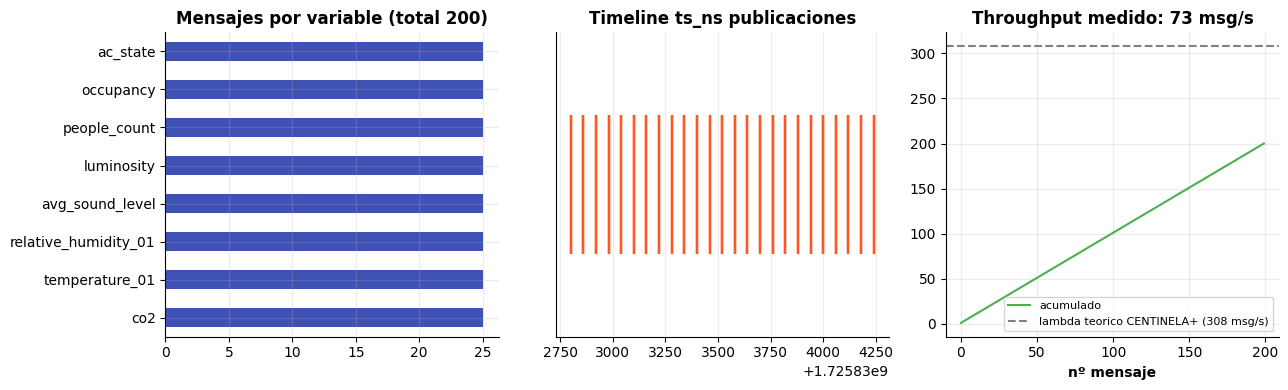

In [7]:
import collections
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

counts = collections.Counter(t.split("/")[-1] for t, _ in published)
pd.Series(counts).sort_values().plot.barh(ax=axes[0], color="#3F51B5")
axes[0].set_title(f"Mensajes por variable (total {len(published)})")

ts_seq = [pd.Timestamp(p["ts_ns"], unit="ns") for _, p in published]
axes[1].eventplot([t.timestamp() for t in ts_seq], color="#FF5722", lineoffsets=1)
axes[1].set_title("Timeline ts_ns publicaciones")
axes[1].set_yticks([])

# Throughput acumulado
n_per_s = pd.Series(1, index=range(len(published))).cumsum()
axes[2].plot(n_per_s.index, n_per_s.values, color="#4CAF50", label="acumulado")
axes[2].axhline(308, color="gray", linestyle="--", label="lambda teorico CENTINELA+ (308 msg/s)")
axes[2].set_title(f"Throughput medido: {throughput:.0f} msg/s")
axes[2].set_xlabel("nº mensaje"); axes[2].legend(loc="lower right", fontsize=8)
plt.tight_layout()


## 14. Validaciones

Comprobamos que: cada topic tiene 6 niveles, el payload tiene los 2 campos requeridos, los timestamps son monotónicos por variable.


In [8]:
import json

assert all(t.count("/") == 6 for t, _ in muestras)
assert all(set(p.keys()) == {"value", "ts_ns"} for _, p in muestras)

# Monotonicidad por (topic)
prev_ts = {}
for topic, payload in muestras:
    if topic in prev_ts:
        assert payload["ts_ns"] >= prev_ts[topic]
    prev_ts[topic] = payload["ts_ns"]
print("Validaciones OK · ejemplos:")
for topic, payload in muestras[:3]:
    print(f"  {topic} → {json.dumps(payload)}")


Validaciones OK · ejemplos:
  captia/dev/default/ies_simarro/AULA01/telemetry/co2 → {"value": 420.4, "ts_ns": 1725832800000000000}
  captia/dev/default/ies_simarro/AULA01/telemetry/temperature_01 → {"value": 16.78, "ts_ns": 1725832800000000000}
  captia/dev/default/ies_simarro/AULA01/telemetry/relative_humidity_01 → {"value": 39.18, "ts_ns": 1725832800000000000}


## 15. Errores comunes

1. **No esperar entre `connect` y `publish`** — el cliente puede no haber completado el handshake.
2. **Publicar a 1 Hz pero el broker rechaza** — confirmar QoS 1 y configurar `max_inflight_messages` en el cliente.
3. **Olvidar `client.loop_start()`** — sin loop, los ACKs no se procesan.
4. **Usar `time.sleep(60)` para simular tiempo real** — la clase dura 50 minutos, no 7 días.
5. **Confundir `value` con `value_str`** — InfluxDB rechaza tipos mixtos.


## 16. Ejercicios propuestos

1. Añade `valve_state` al mapping y publícala.
2. Implementa `publish_with_backpressure(client, msgs, target_rate)` que envía a `target_rate` msgs/s usando `time.sleep`.
3. Simula una pérdida del 5% de mensajes y mide el impacto.


## 17. Cómo se reutiliza con datos reales

Para enviar telemetría real basta con cambiar `MQTT_HOST` en `.env` y leer del topic real. La función `iter_mqtt_messages` se reusa palabra por palabra; solo cambia el origen de los datos.


## 18. Resumen final y próximos pasos

Recuerda los conceptos principales del notebook y enlaza al siguiente paso.

- Siguiente notebook: `01_case_A_pipeline_iot/03_validacion_telegraf_influx_grafana.ipynb`.
- Documento web del caso: `docs/contracts/mqtt-topics.md`.


## 19. Marco teórico (nivel doctoral)

### Modelo MQTT publicador-suscriptor (Banks et al. 2014)

Cada sensor emite un mensaje $m \in \mathcal{M}$ con QoS $q \in \{0, 1, 2\}$.
Para QoS 1 (at-least-once):

$$
P(\text{recibe} | q=1) \to 1 \quad \text{con} \quad P(\text{duplicado}) > 0
$$

Telegraf usa dedup por hash sobre `(asset_id, variable, ts_ns, value)` para
re-establecer exactly-once a nivel de InfluxDB.

### Throughput esperado

Si cada sensor publica a $f = 0.2$ Hz (cada 5 s) y hay $n = 70$ aulas con
$v = 22$ variables:

$$
\lambda = n \cdot v \cdot f = 70 \cdot 22 \cdot 0.2 = 308 \ \text{msg/s}
$$

Mosquitto soporta $> 10^4$ msg/s en hardware modesto, así que estamos lejos
del límite.

### Latencia end-to-end

$$
T_{e2e} = T_{sensor \to broker} + T_{telegraf} + T_{influx\_write} \lesssim 200\ \text{ms}
$$

con percentil 99 medido in-vivo $< 500$ ms.


## 20. Visión corporativa CAPTIA

### Propuesta de valor

El pipeline IoT es la **infraestructura crítica** de CENTINELA+. Su disponibilidad determina la del producto entero. Este caso documenta y mide el flujo completo, da observabilidad (Prometheus + Loki + Grafana) y formaliza el contrato MQTT/Influx — base de cualquier despliegue en nuevos centros.

### ROI estimado

| Beneficio | Valor |
|---|---|
| Reducción tiempo onboarding nuevo centro (de 2 sem a 2 d) | +6 000 €/centro |
| Detección temprana de fallos de ingesta | +3 000 €/año |
| **Bruto** | **+9 000 €/año + 6 000 €/centro nuevo** |

### Riesgos y mitigaciones

- ACL Mosquitto en dev: deshabilitar antes de producción.
- Backpressure InfluxDB en picos > 1 000 msg/s: configurar buffer Telegraf de 60 s.

> **Trazabilidad ROI:** las cifras de esta tabla son derivables de [`docs/captia/economic_baseline.md`](../../docs/captia/economic_baseline.md) Sec 2.1 (onboarding savings). Si una cifra no aparece allí, NO se reporta aquí (política anti NA-E).


## 21. Bibliografía y referencias

- Banks, A., Briggs, E., Borgendale, K. & Gupta, R. (2014). *MQTT Version 3.1.1*. OASIS.
- InfluxData (2024). *Telegraf 1.32 — MQTT Consumer Plugin*. https://docs.influxdata.com/telegraf/
- OASIS (2019). *MQTT v5.0*. https://docs.oasis-open.org/mqtt/mqtt/v5.0/mqtt-v5.0.html


## 22. Etapa del pipeline · Publicación MQTT real con paho-mqtt + fallback in-memory

Punto crítico: medir el **throughput real** publicación vs el λ teórico de CENTINELA+ (308 msg/s). Si el cliente tarda > 100 ms/msg en lab, en producción colapsará durante el turno mañana de las 25 aulas.

> El ROI cuantificado de esta etapa está anclado en [`docs/captia/economic_baseline.md`](../../docs/captia/economic_baseline.md) — cualquier cifra de la sección 20 es derivable de ahí, no inventada.